#[Assignment 11] Classification Using Pre-trained Models (Feature Extractors)

In this assignment, your task is to employ a classifier on the features extracted from a pre-trained vision transformer included in CLIP.

Reference: https://openai.com/research/clip


#Step 1: System Setup
<font color=red> Before executing any commands, ensure that the runtime is configured for GPU.</font>

## Step 1.1: Importing Base Modules





In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image

## Step 1.2: Load the Dataset

In this assignment, you will work with a dataset called **Fashion-MNIST**. This dataset contains images (60000 for training and 10000 for testing) labeled with 10 different classes:

* 0 - T-shirt/top
* 1 - Trouser
* 2 - Pullover
* 3 - Dress
* 4 - Coat
* 5 - Sandal
* 6 - Shirt
* 7 - Sneaker
* 8 - Bag
* 9 - Ankle boot

You can read more about the dataset here: https://github.com/zalandoresearch/fashion-mnist


In [2]:
from keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

Let's see the size of the arrays

In [3]:
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

Let's look at some of the sample images

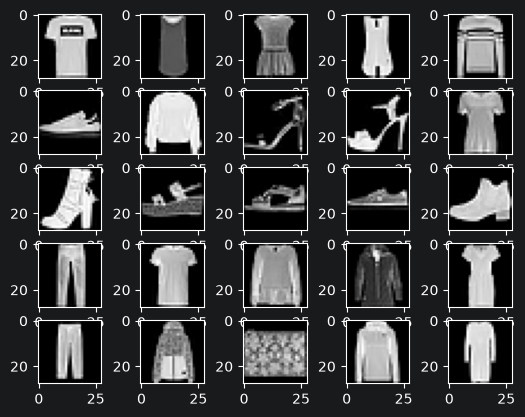

In [4]:
import matplotlib.pyplot as plt
for i in range(1,26):
  plt.subplot(5,5,i)
  plt.imshow(X_train[i],cmap='gray')

## Step 1.3: Setup CLIP enviroment

We will install CLIP and set up our environment to leverage the GPU. Following that, we'll load a ResNet-50 model, `RN50`, from the CLIP models. Do not change the model in this assignemnt but feel free to explore other available models in the package.

In [5]:
# !pip install git+https://github.com/openai/CLIP.git
import clip

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load('RN50', device=device)
print(device)

cuda


##Step 1.4: Encoding Text Labels
Create a list called `label_texts` that consists of string labels for this dataset. You can use either a sentence for each class or simply a single word.

In [7]:
label_texts= ["t-shirt","trouser","pull-over","dress","coat","sandal","shirt","sneaker","bag","ankle-boot"]

Tokenize (encode) the `label_texts` using CLIP and store the tokens in a variable named `label_texts_tokens`.

In [8]:
# Make sure to stick it on the right device.
label_texts_tokens = clip.tokenize(label_texts).to(device)

In [9]:
#Executing the following code should print True if you have written your code correctly.
label_texts_tokens.shape==torch.Size([10, 77])

True

#Step 2: Model direct output (No added classifier)

In this section, we will input all the images from the test data into the CLIP model along with the text labels we have created to observe how it predicts the output.

Following the lecture code:

Loop through all images in the test set, `X_test`.
For each image, apply preprocessing and then use the model to extract features. Append these features to the list named `X_test_CLIP_features`.
Compute the logits and then determine the matching probabilities with the texts in `label_texts_tokens`. The highest probability indicates the predicted class. `np.argmax(probabilities)` will provide the index of the label with the highest probability.
Append the predicted label (class) to `y_test_predicted_direct`.

<font color=blue>Do everything in one loop and it should take ~7 minutes to finish.



In [10]:
from keras.utils import Progbar

y_test_predicted_direct = []
X_test_CLIP_features = []
progress_bar = Progbar(len(X_test))

with torch.no_grad():
  for pic in X_test:
    image = preprocess(Image.fromarray(pic).convert("RGB")).unsqueeze(0).to(device)
    image_features = model.encode_image(image)
    X_test_CLIP_features.append(image_features)

    logits_per_image, logits_per_text = model(image, label_texts_tokens)
    # Bring back from GPU.
    probabilities = logits_per_image.softmax(dim=-1).cpu().numpy()[0]
    y_test_predicted_direct.append(np.argmax(probabilities))
    progress_bar.add(1)


10000/10000 ━━━━━━━━━━━━━━━━━━━━ 299s 30ms/step


In [11]:
##Executing the following code should print True if you have written your code correctly and have 10000 predicted labels
len(y_test_predicted_direct)==10000

True

In [12]:
##Executing the following code should print True if you have written your code correctly and have 10000 feature sets
len(X_test_CLIP_features)==10000

True

In [13]:
##Executing the following code should print True if you have written your code correctly and have 1024 features for each image
X_test_CLIP_features[0].shape==torch.Size([1, 1024])

True

Run the following command to see the prediction result on the test data.

              precision    recall  f1-score   support

           0       0.33      0.78      0.46      1000
           1       0.28      0.99      0.43      1000
           2       0.03      0.00      0.01      1000
           3       0.90      0.17      0.29      1000
           4       0.54      0.45      0.49      1000
           5       0.06      0.00      0.00      1000
           6       0.51      0.03      0.06      1000
           7       0.64      0.95      0.76      1000
           8       0.93      0.46      0.61      1000
           9       0.81      0.71      0.76      1000

    accuracy                           0.45     10000
   macro avg       0.50      0.45      0.39     10000
weighted avg       0.50      0.45      0.39     10000



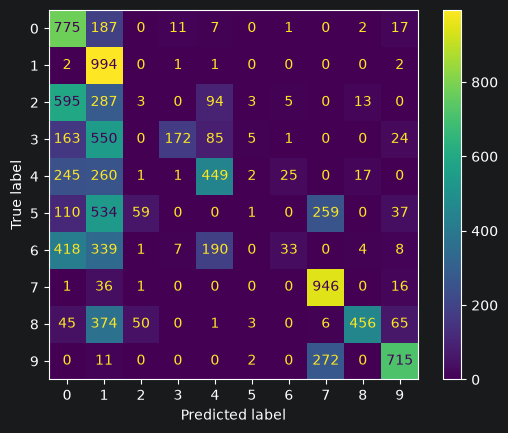

In [14]:
from sklearn.metrics  import classification_report,confusion_matrix,ConfusionMatrixDisplay,f1_score

print(classification_report(y_test,y_test_predicted_direct))
ConfusionMatrixDisplay(confusion_matrix(y_test,y_test_predicted_direct)).plot()

#Step 3: Extracted Features + Classifier
In this step, we will apply a classifier to the extracted features to evaluate if we can achieve better results.

##Step 3.1: Extracting features for the training data
Run a code similar to what you executed for the test data to extract features for the training data.

Please note that you only need the features, so **do not** calculate the logits and probabilities.

<font color=red>Perform all the steps within a single loop, and it should take approximately 10 minutes to complete.

In [15]:
X_train_CLIP_features = []
progress_bar = Progbar(len(X_train))

with torch.no_grad():
  for pic in X_train:
    image = preprocess(Image.fromarray(pic).convert("RGB")).unsqueeze(0).to(device)
    image_features = model.encode_image(image)
    X_train_CLIP_features.append(image_features.cpu().numpy()[0])
    progress_bar.add(1)


60000/60000 ━━━━━━━━━━━━━━━━━━━━ 639s 11ms/step


##Step 3.2: Train a linear classifier - Logistic regression.

Choose the classifier parameters in a manner that avoids any warnings; the model **must** converge.`max_iter` should not be more than 100.

In [16]:
from sklearn.linear_model import LogisticRegression

LGR = LogisticRegression(max_iter=100, solver='saga', C=0.1,
                         tol=0.01)  #fill the model parameters inside the paranthesis.

#Do not change the line below
LGR.fit(X_train_CLIP_features, y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.01
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'saga'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio

Predict the labels using the model trained above `LGR` for the testing dataset.

In [17]:
y_test_predicted_LGR = LGR.predict([features.cpu().numpy()[0] for features in X_test_CLIP_features])


Run the following command to see the prediction result on the test data.

              precision    recall  f1-score   support

           0       0.80      0.78      0.79      1000
           1       0.97      0.95      0.96      1000
           2       0.74      0.80      0.77      1000
           3       0.78      0.82      0.80      1000
           4       0.71      0.74      0.73      1000
           5       0.90      0.92      0.91      1000
           6       0.65      0.52      0.58      1000
           7       0.90      0.90      0.90      1000
           8       0.94      0.95      0.94      1000
           9       0.93      0.93      0.93      1000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



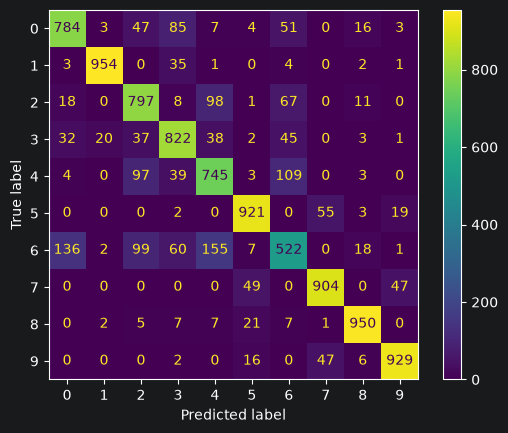

In [18]:
from sklearn.metrics  import classification_report,confusion_matrix,ConfusionMatrixDisplay,f1_score

print(classification_report(y_test,y_test_predicted_LGR))
ConfusionMatrixDisplay(confusion_matrix(y_test,y_test_predicted_LGR)).plot()

##Step 3.3: Train a non linear classifier - MLP (with hidden layer)

Ensure the inclusion of a hidden layer, `hidden_layer_sizes` in the model parameters to make the classifier non-linear.

Change the parameters until you achieve an **accuracy of 89%** on the test subset.

*   The fewer the number of perceptrons in the hidden layer, the better, as it indicates a model with fewer weights.

*   Setting a smaller value for `max_iter` is preferable, as it means the model will converge faster.

In [35]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

X_train_MLP_features = np.asarray(X_train_CLIP_features)
X_test_MLP_features = np.asarray([features.cpu().numpy()[0] for features in X_test_CLIP_features])

scaler = StandardScaler()
X_train_MLP_features_scaled = scaler.fit_transform(X_train_MLP_features)
X_test_MLP_features_scaled = scaler.transform(X_test_MLP_features)

# Bracket searched 50,100
hidden_size = (75,)
MLP = MLPClassifier(hidden_layer_sizes=hidden_size, early_stopping=True, max_iter=100, random_state=42, activation='relu', solver='adam')
MLP.fit(X_train_MLP_features_scaled, y_train)
y_test_predicted_MLP = MLP.predict(X_test_MLP_features_scaled)
MLP_accuracy = np.mean(y_test_predicted_MLP == y_test)

print("Best MLP stats:")
print(f"Hidden layer size: {hidden_size}")
print(f"Accuracy: {MLP_accuracy:.4f}")


Best MLP stats:
Hidden layer size: (75,)
Accuracy: 0.8908


Predict the labels using the model trained above `MLP` for the testing dataset.

In [36]:
y_test_predicted_MLP = MLP.predict(X_test_MLP_features_scaled)


Run the following command to see the prediction result on the test data.

              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1000
           1       0.99      0.98      0.98      1000
           2       0.83      0.86      0.85      1000
           3       0.89      0.87      0.88      1000
           4       0.85      0.83      0.84      1000
           5       0.98      0.95      0.96      1000
           6       0.70      0.70      0.70      1000
           7       0.92      0.96      0.94      1000
           8       0.97      0.98      0.97      1000
           9       0.95      0.94      0.95      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



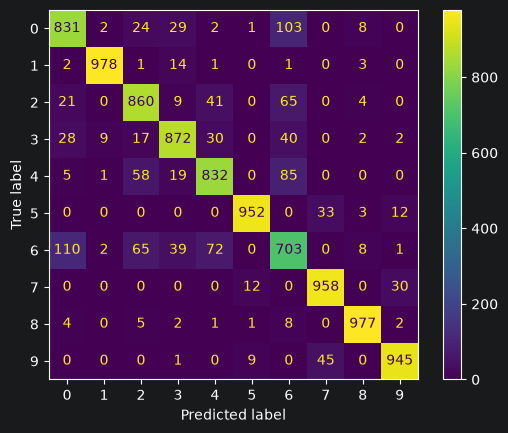

In [37]:
from sklearn.metrics  import classification_report,confusion_matrix,ConfusionMatrixDisplay,f1_score

print(classification_report(y_test,y_test_predicted_MLP))
ConfusionMatrixDisplay(confusion_matrix(y_test,y_test_predicted_MLP)).plot()

#Step 4: Justification

Please provide your responses to the following questions in the text box below.

1) What was the overall accuracy achieved in the previous assignment (Assignment 10) with the MLP?

2) Why doesn't using the CLIP-RESNET50 model directly produce acceptable results?

3) Why did adding a classifier to CLIP lead to an improvement in results?

4) How did the inclusion of a hidden layer in the MLP contribute to the improvement in results?

## Answers to questions
1. Overall accuracy I achieved was 90% on training set, and 84% on testing set.
2. CLIP-RESNET50 is a general model, which means it needs to be _generally_ decent, not specifically accurate on this subset. This is the exact reason why we fine-tune models on downstream tasks.
3. Adding a classifier to CLIP allows us to fine-tune the mapping of the CLIP-RESNET50 model features to the token classification features. If the label I chose is not exactly what the model was trained, you'll see a drop in accuracy out of the gate due to embedding feature mismatch.
4. The inclusion of a hidden layer in the MLP allows the model to learn nonlinear mapping between the RESNET50 features and the token classification features. Right now, the MLP has one hidden layer, and I had tried (unsuccessfully) to make it a smaller set of multiple hidden layers. For instance, 10x10 gets around 86% accuracy. 5x5x5 gets around 86% accuracy. Actually reaching 89%+ was surprisingly hard. I did do some AI-advised research on the best pairings of optimizers and activations.